In [1]:
# This is what I'm gonna need for the wavelet transform
import sys
sys.path.append("/home/r/Robert.Reichert/juwavelet")
import juwavelet.transform as transform
from juwavelet import utils

# This is for the data preprocessing and the segmentation
sys.path.append('../scripts')
import utils_2d as two
import plot_tools as pt
import utils_AWE as awe

import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy

plt.style.use("../latex_default_AMT.mplstyle")

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
data_path = '../data/awe_l3c_q20_2024108T0214_02279_v01.nc'
ds = xr.open_dataset(data_path)

In [3]:
orig = ds["Radiance"].isel(time=0,x_along_track=slice(400,1100),y_cross_track=slice(140,-57))
nanmask = np.isfinite(orig)
if np.sum(~nanmask) > 0:
    print('orig contains Nan values!')
orig_copy = orig.copy()
BI_high, BI_low = two.BG_removal(orig_copy.values,max_order=1)
dx, dy = 2000, 2000
nx, ny = orig['x_along_track'].size, orig['y_cross_track'].size
y = np.linspace(0,(ny-1)*dy,ny)*1e-3
x = np.linspace(0,(nx-1)*dx,nx)*1e-3
print('Domain size:', nx, ny)

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(BI_high, ntap, window='tukey')

Domain size: 700 254


In [4]:
s0 = 4 #smallest scale that we wanna resolve
s1 = 0.5 * min([nx,ny]) #largest scale we wanna resolve (since the first Fourier component is part of the background (BI_low) the largest scale fits twice in the domain)
dj = 1 / 8 # apäter wieder dj=1/8
js = int(1/dj*np.log2(s1/s0))
jt = 21
print('Decomposition shape will be: ', js, jt, nx, ny)

cwt_result = transform.decompose2d(signal,dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,nxpad=None,nypad=None,opts={'param': 2*np.pi},mode="scaled",dtype=np.complex128)

print(f"The data resolution is {dx*1e-3:.0f} km and the smallest wavelength you analyze is {cwt_result['period'][0]*1e-3:.0f} km.")
print(f"The data domain is at least {min([nx,ny])*dx*1e-3:.0f} km and the largest wavelength you analyze is {cwt_result['period'][-1]*1e-3:.0f} km.")

Decomposition shape will be:  39 21 700 254


/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))


The data resolution is 2 km and the smallest wavelength you analyze is 8 km.
The data domain is at least 508 km and the largest wavelength you analyze is 215 km.


/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


In [5]:
# Denoising
noise_floor = 0.2 #units of BI
wavy_stuff, denoised_cwt = two.denoise_2d(cwt_result,white_noise_level=noise_floor,sMAD_threshold=3)

Text(0.03, 0.94, 'c')

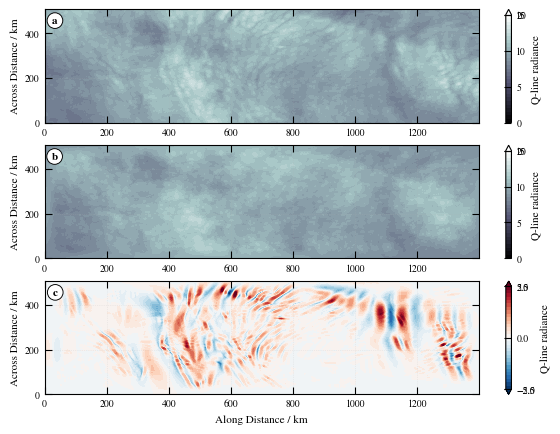

In [6]:
BI_lev = np.linspace(0,15,31)
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(311)
plot_orig = ax1.contourf(x,y,orig,levels=BI_lev,extend='max',cmap='bone')
cbar = fig.colorbar(plot_orig,ticks=[0,5,10,15,20],label='Q-line radiance')

ax2 = fig.add_subplot(312)
plot_dirt = ax2.contourf(x,y,BI_low+signal-wavy_stuff+np.mean(orig.values),levels=BI_lev,extend='max',cmap='bone')
cbar = fig.colorbar(plot_dirt,ticks=[0,5,10,15,20],label='Q-line radiance')

ax3 = fig.add_subplot(313)
plot_wave = ax3.contourf(x,y,wavy_stuff,levels=np.linspace(-1,1,31),extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_wave,ticks=[-5,-2.5,0,2.5,5],label='Q-line radiance')

ax3.set_xlabel('Along Distance / km')
ax1.set_ylabel('Across Distance / km')
ax2.set_ylabel('Across Distance / km')
ax3.set_ylabel('Across Distance / km')

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
ax1.text(0.03,0.94,'a',transform=ax1.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax2.text(0.03,0.94,'b',transform=ax2.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax3.text(0.03,0.94,'c',transform=ax3.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 

#plt.savefig('./figures/2D_example_AWE_BG_removal.png',dpi=300,bbox_inches="tight",pad_inches=0.02)

In [6]:
import time

In [9]:
noise = np.random.normal(0,noise_floor,(nx,ny))
noise_cwt = transform.decompose2d(noise, dx, dy, s0, dj, js, jt, aspect=1, opts={'param': 2*np.pi}, mode='scaled', dtype=np.complex128)
a, b, noise_WAS = two.fit_power_law(noise_cwt['scale'],np.mean(np.abs(noise_cwt['decomposition']),axis=(1,2,3)))

WAS        = np.abs(denoised_cwt['decomposition'])
start  = time.perf_counter()
seg_v1 = two.wavefield_segmentation_2d(WAS/noise_WAS[:,None,None,None],1,connectivity_order=2)
end    = time.perf_counter()
print(f"Runtime: {end - start:.6f} seconds")
print('Identified', np.max(seg_v1), 'initial wave packets!')

WP_labels      = np.arange(1,np.max(seg_v1)+1)
start          = time.perf_counter()
cluster_labels = two.find_clusters_in_freq_theta_numba(denoised_cwt, seg_v1, eps=0.1)
end            = time.perf_counter()
print(f"Runtime: {end - start:.6f} seconds")

cluster_map    = two.build_cluster_map_with_noise(WP_labels,cluster_labels)
seg_v2         = two.relabel_by_xy_overlap(seg_v1, cluster_map)
print('Reduced the number of wave packets to', np.max(seg_v2))

seg_v3         = two.variance_filter(denoised_cwt, seg_v2, var_threshold=0.99)
print('Final number of wave packets:', np.max(seg_v3))

Reduced the number of wave packets to 9
Final number of wave packets: 3


In [10]:
recon_WP1, amp_WP1, k_along_WP1, k_across_WP1 = two.recon_WPoi_2d(denoised_cwt,seg_v3,[1])

100%|██████████| 177800/177800 [00:06<00:00, 27614.64it/s]


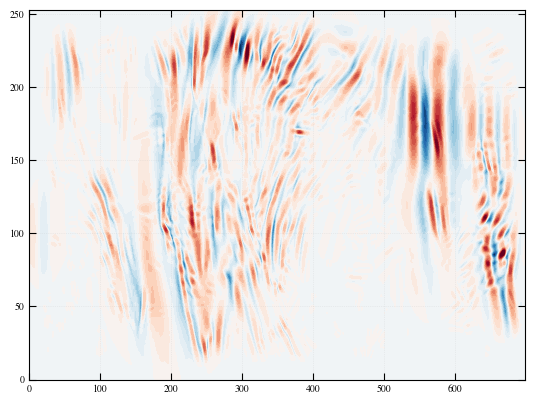

In [11]:
plt.contourf(recon_WP1,levels=np.linspace(-1,1,31),cmap='RdBu_r',extend='both')

In [12]:
recon_WP1, amp_WP1, k_along_WP1, k_across_WP1 = two.recon_WPoi_2d(denoised_cwt,seg_v3,[2])

100%|██████████| 177800/177800 [00:02<00:00, 59623.57it/s]


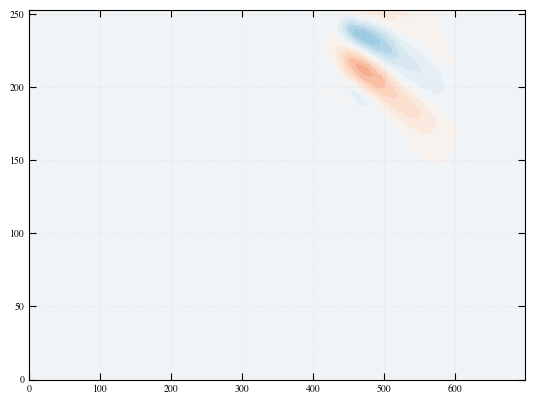

In [13]:
plt.contourf(recon_WP1,levels=np.linspace(-1,1,31),cmap='RdBu_r',extend='both')

In [14]:
recon_WP1, amp_WP1, k_along_WP1, k_across_WP1 = two.recon_WPoi_2d(denoised_cwt,seg_v3,[3])

100%|██████████| 177800/177800 [00:03<00:00, 54252.39it/s]


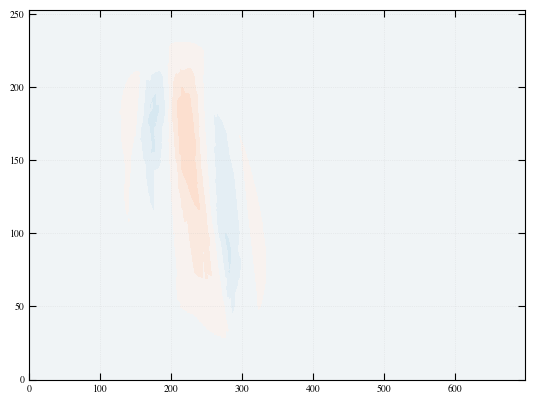

In [15]:
plt.contourf(recon_WP1,levels=np.linspace(-1,1,31),cmap='RdBu_r',extend='both')